# Pattern Generation with Gurobi

This notebook demonstrates how Game of Life still-life patterns are generated using Gurobi optimization.

## Overview

The tiles used in Game of Life mosaics are **still-lifes**: stable patterns in Conway's Game of Life that don't change over time. We generate these patterns with specific properties:

1. **8-fold symmetry**: Patterns are symmetric under all rotations and reflections
2. **Stable**: Each cell has exactly 2-3 living neighbors (Game of Life rule)
3. **Controlled density**: We can specify the fraction of living cells

We use **Integer Linear Programming (ILP)** with Gurobi to find patterns satisfying these constraints.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from gol_mosaics import PatternLibrary

# Note: This notebook requires a Gurobi license
# Academic licenses are free: https://www.gurobi.com/academia/
try:
    import gurobipy as gp
    from gurobipy import GRB
    print("✓ Gurobi is installed")
except ImportError:
    print("✗ Gurobi not found. Install with: pip install gurobipy")
    print("  (Requires license - free for academics)")

✓ Gurobi is installed


## Step 1: Understanding Still-Lifes

In Conway's Game of Life, a still-life is a pattern where every living cell has exactly 2 or 3 living neighbors, and every dead cell has 0, 1, 2, 4, 5, 6, 7, or 8 living neighbors (anything except 3).

Let's visualize some example still-lifes from different density levels:

Level 4 patterns: 85 patterns
Pattern size: (24, 24)
Density range: 0.000 to 1.000


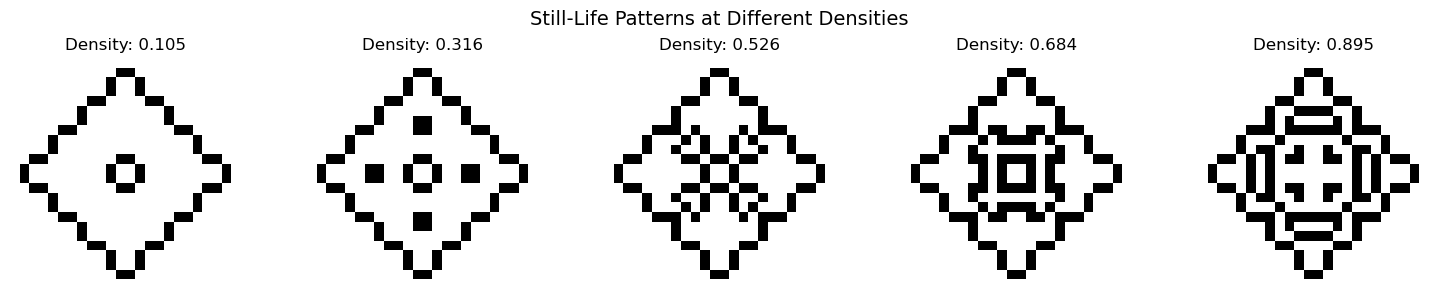

In [9]:
# Load pre-computed patterns
level=4
library = PatternLibrary.load(level=level)

print(f"Level {level} patterns: {len(library.solutions)} patterns")
print(f"Pattern size: {library.solutions.shape[1:]}")
print(f"Density range: {library.densities.min():.3f} to {library.densities.max():.3f}")

# Show patterns at different densities
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
densities_to_show = [0.1, 0.3, 0.5, 0.7, 0.9]

for ax, target_density in zip(axes, densities_to_show):
    # Find pattern closest to target density
    idx = np.argmin(np.abs(library.densities - target_density))
    pattern = library.solutions[idx]
    actual_density = library.densities[idx]
    
    ax.imshow(pattern, cmap='binary', interpolation='nearest')
    ax.set_title(f'Density: {actual_density:.3f}')
    ax.axis('off')

plt.suptitle('Still-Life Patterns at Different Densities', fontsize=14)
plt.tight_layout()
plt.show()

## Step 2: The Pond Pattern

Before we dive into Gurobi, let's examine the "pond" pattern - a fundamental building block for our still-life patterns.

The pond is the simplest 8-fold symmetric still-life. We can:
1. Use it as-is (4×4 basic pond)
2. Tile multiple ponds together into a diamond shape
3. Extract just the edge/border (which is also a still-life!)

These pond patterns serve as starting points or constraints in the optimization process.

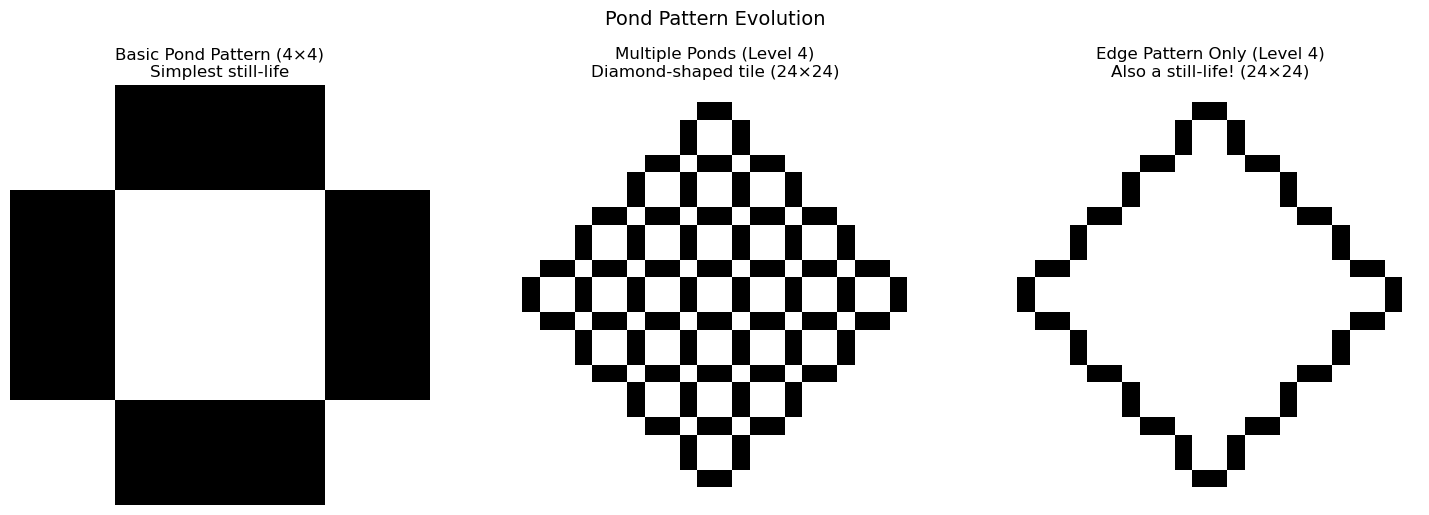

Basic pond: (4, 4), density: 0.500
Multiple ponds: (24, 24), density: 0.222
Edge pattern: (24, 24), density: 0.097

The edge pattern extracts only the border, creating a hollow still-life!


In [10]:
# Show the three types of pond patterns
# Use the library from Step 1, or create a level 4 instance for pond patterns
library_level4 = PatternLibrary.load(level=4)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Basic pond pattern (4x4)
basic_pond = PatternLibrary.pond_pattern()
axes[0].imshow(basic_pond, cmap='binary', interpolation='nearest')
axes[0].set_title('Basic Pond Pattern (4×4)\nSimplest still-life', fontsize=12)
axes[0].axis('off')
axes[0].set_xticks(np.arange(-0.5, 4, 1), minor=True)
axes[0].set_yticks(np.arange(-0.5, 4, 1), minor=True)
axes[0].grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# 2. Multiple ponds glued together
pond_multiple = library_level4.pond_pattern_multiple()
axes[1].imshow(pond_multiple, cmap='binary', interpolation='nearest')
axes[1].set_title(f'Multiple Ponds (Level 4)\nDiamond-shaped tile ({pond_multiple.shape[0]}×{pond_multiple.shape[1]})', fontsize=12)
axes[1].axis('off')

# 3. Edge pattern only
pond_edge = library_level4.pond_pattern_edge()
axes[2].imshow(pond_edge, cmap='binary', interpolation='nearest')
axes[2].set_title(f'Edge Pattern Only (Level 4)\nAlso a still-life! ({pond_edge.shape[0]}×{pond_edge.shape[1]})', fontsize=12)
axes[2].axis('off')

plt.suptitle('Pond Pattern Evolution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Basic pond: {basic_pond.shape}, density: {basic_pond.sum()/basic_pond.size:.3f}")
print(f"Multiple ponds: {pond_multiple.shape}, density: {pond_multiple.sum()/pond_multiple.size:.3f}")
print(f"Edge pattern: {pond_edge.shape}, density: {pond_edge.sum()/pond_edge.size:.3f}")
print("\nThe edge pattern extracts only the border, creating a hollow still-life!")

## Step 3: 8-Fold Symmetry

To create mosaics with a diamond/diagonal layout, we need patterns with 8-fold symmetry:
- 4 rotational symmetries (90°, 180°, 270°, 360°)
- 4 reflection symmetries (horizontal, vertical, 2 diagonals)

This means we only need to solve for 1/8 of the pattern - the rest is determined by symmetry!

_Note_: in group theory, this is called the dihedral group $D_4$.

Let's visualize this:

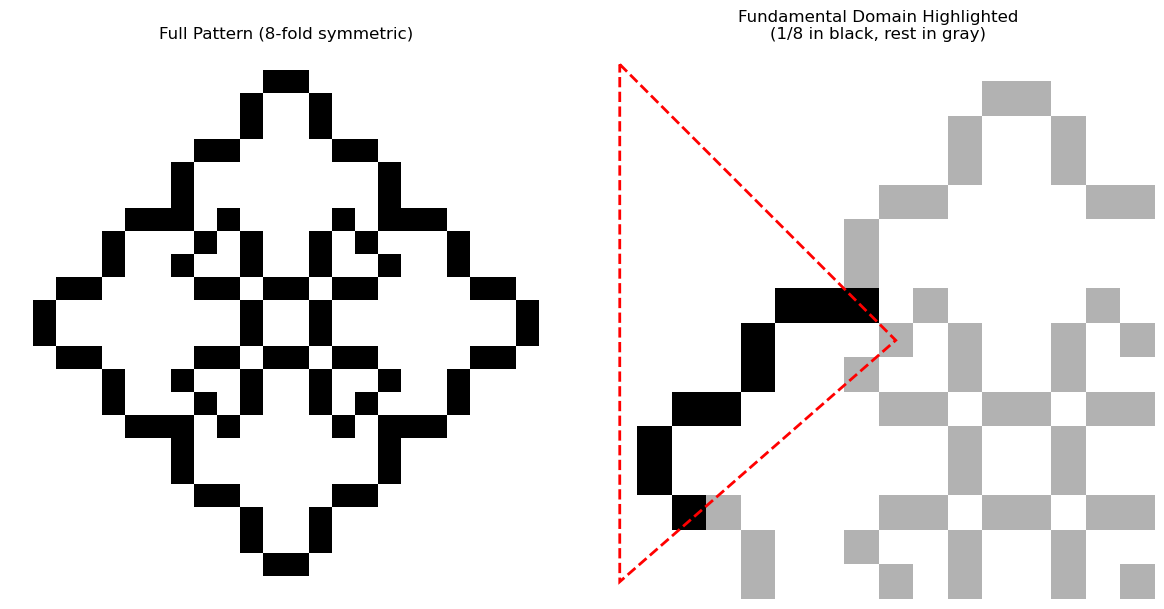

Full pattern: 16×16 = 256 cells
Fundamental domain: ~32 cells (only these need optimization)
The other 7/8 are copied via symmetry transformations.

Red outline shows the fundamental domain boundary.


In [11]:
# Show the fundamental domain (1/8 of pattern)
size = 16
pattern = library.solutions[40]  # Pick an example pattern

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: Full pattern in black
axes[0].imshow(pattern, cmap='binary', interpolation='nearest')
axes[0].set_title('Full Pattern (8-fold symmetric)', fontsize=12)
axes[0].axis('off')

# Right: Pattern in light gray with 1/8th highlighted in black
# Create RGB image for better control
highlighted = np.ones((size, size, 3))  # Start with white

for i in range(size):
    for j in range(size):
        if pattern[i, j] == 1:
            # Fundamental domain (upper-left triangle): black
            if j <= i and i + j < size:
                highlighted[i, j] = [0, 0, 0]  # Black
            else:
                highlighted[i, j] = [0.7, 0.7, 0.7]  # Light gray

axes[1].imshow(highlighted, interpolation='nearest')
axes[1].set_title('Fundamental Domain Highlighted\n(1/8 in black, rest in gray)', fontsize=12)
axes[1].axis('off')

# Add outline to show the fundamental region
from matplotlib.patches import Polygon
triangle = Polygon([(0, 0), (size/2, size/2), (0, size-1)], 
                   fill=False, edgecolor='red', linewidth=2, linestyle='--')
axes[1].add_patch(triangle)

plt.tight_layout()
plt.show()

print(f"Full pattern: {size}×{size} = {size*size} cells")
print(f"Fundamental domain: ~{size*size//8} cells (only these need optimization)")
print("The other 7/8 are copied via symmetry transformations.")
print("\nRed outline shows the fundamental domain boundary.")

## Step 4: Setting Up the ILP Problem

Now let's set up the Integer Linear Programming problem for Gurobi.

### Variables
- Binary variable for each cell: `x[i,j] ∈ {0, 1}` (0 = dead, 1 = alive)

### Constraints
1. **Still-life constraint**: Each living cell has 2 or 3 living neighbors
2. **No birth constraint**: Each dead cell does NOT have exactly 3 neighbors
3. **Symmetry constraint**: Pattern must be 8-fold symmetric
4. **Density constraint**: Total number of living cells ≈ target density

Let's implement this step-by-step:

In [12]:
def count_neighbors(x, i, j, N):
    """
    Count living neighbors for cell (i,j) using Gurobi variables.
    
    Returns a Gurobi linear expression.
    """
    neighbors = []
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue  # Skip the cell itself
            
            ni, nj = i + di, j + dj
            
            # Boundary conditions (treat out-of-bounds as dead)
            if 0 <= ni < N and 0 <= nj < N:
                neighbors.append(x[ni, nj])
    
    return sum(neighbors) if neighbors else 0

print("Neighbor counting function defined.")
print("For a cell at (i,j), this sums the 8 surrounding cells.")

Neighbor counting function defined.
For a cell at (i,j), this sums the 8 surrounding cells.


In [13]:
def create_symmetric_pattern(x_fundamental, N):
    """
    Expand fundamental domain to full pattern using 8-fold symmetry.
    
    Args:
        x_fundamental: Dict of Gurobi variables for fundamental domain
        N: Pattern size
    
    Returns:
        Full NxN dict of variables (many reference the same variable)
    """
    x = {}
    
    for i in range(N):
        for j in range(N):
            # Generate all 8 symmetric positions
            positions = [
                (i, j),
                (j, i),                    # Reflect across main diagonal
                (N-1-i, j),                # Reflect horizontally  
                (i, N-1-j),                # Reflect vertically
                (N-1-j, i),                # Rotate 90° + reflect
                (j, N-1-i),                # Rotate 270°
                (N-1-i, N-1-j),            # Rotate 180°
                (N-1-j, N-1-i),            # Rotate 270° + reflect
            ]
            
            # Find which of these positions is in the fundamental domain
            # Fundamental domain is: j <= i and i + j < N
            canonical = None
            for pos in positions:
                pi, pj = pos
                if pj <= pi and pi + pj < N:
                    canonical = pos
                    break
            
            if canonical is None:
                # This shouldn't happen with correct symmetry, but handle it
                canonical = min(positions)
            
            # Assign the variable from fundamental domain
            if canonical in x_fundamental:
                x[i, j] = x_fundamental[canonical]
            else:
                # Fallback: create a new variable if needed
                # This shouldn't happen if fundamental domain is correctly defined
                print(f"Warning: Position {canonical} not found in fundamental domain")
                x[i, j] = x_fundamental[min(x_fundamental.keys())]
    
    return x

print("Symmetry expansion function defined.")
print("This ensures all 8 symmetric positions reference the same variable.")
print("Fundamental domain: positions where j <= i and i + j < N")

Symmetry expansion function defined.
This ensures all 8 symmetric positions reference the same variable.
Fundamental domain: positions where j <= i and i + j < N


## Step 5: Solving for a Single Pattern

Let's solve for a single still-life pattern with a target density of 0.5:

In [14]:
def generate_stilllife_pattern(N=16, target_density=0.5, tolerance=0.05):
    """
    Generate a single still-life pattern using Gurobi ILP.
    
    Args:
        N: Pattern size (NxN grid)
        target_density: Desired fraction of living cells (0 to 1)
        tolerance: Allowed deviation from target density
    
    Returns:
        NxN numpy array with 0s and 1s
    """
    # Create model
    model = gp.Model("stilllife")
    model.setParam('OutputFlag', 0)  # Suppress output
    model.setParam('TimeLimit', 30)  # 30 second timeout
    
    # Create variables for fundamental domain only
    x_fund = {}
    for i in range(N):
        for j in range(N):
            if j <= i and i + j < N:  # Upper-left triangle
                x_fund[i, j] = model.addVar(vtype=GRB.BINARY, name=f'x_{i}_{j}')
    
    # Expand to full pattern using symmetry
    x = create_symmetric_pattern(x_fund, N)
    
    # Add Game of Life constraints
    for i in range(N):
        for j in range(N):
            neighbors = count_neighbors(x, i, j, N)
            
            # If cell is alive, it must have 2 or 3 neighbors
            # This is: x[i,j]=1 => neighbors in {2,3}
            # Implemented as: neighbors >= 2*x[i,j] and neighbors <= 3*x[i,j] + 8*(1-x[i,j])
            model.addConstr(neighbors >= 2 * x[i, j], f'alive_min_{i}_{j}')
            model.addConstr(neighbors <= 3 * x[i, j] + 8 * (1 - x[i, j]), f'alive_max_{i}_{j}')
            
            # If cell is dead, it must NOT have exactly 3 neighbors
            # This prevents births: (1-x[i,j])=1 => neighbors != 3
            # We use auxiliary binary variable to enforce this
            z = model.addVar(vtype=GRB.BINARY, name=f'z_{i}_{j}')
            model.addConstr(neighbors <= 3 - 0.1 + 10 * z, f'dead_neq3a_{i}_{j}')
            model.addConstr(neighbors >= 3 + 0.1 - 10 * (1 - z - x[i, j]), f'dead_neq3b_{i}_{j}')
    
    # Add density constraint
    total_cells = N * N
    target_alive = int(target_density * total_cells)
    tolerance_cells = int(tolerance * total_cells)
    
    total_alive = sum(x[i, j] for i in range(N) for j in range(N))
    model.addConstr(total_alive >= target_alive - tolerance_cells, 'density_min')
    model.addConstr(total_alive <= target_alive + tolerance_cells, 'density_max')
    
    # Dummy objective (we just want feasibility)
    model.setObjective(0, GRB.MINIMIZE)
    
    # Solve
    print(f"Solving ILP for density {target_density:.2f}...")
    model.optimize()
    
    if model.status == GRB.OPTIMAL or model.status == GRB.SUBOPTIMAL:
        # Extract solution
        pattern = np.zeros((N, N), dtype=int)
        for i in range(N):
            for j in range(N):
                if x[i, j].X > 0.5:  # Binary variable is 1
                    pattern[i, j] = 1
        
        actual_density = pattern.sum() / pattern.size
        print(f"✓ Found pattern with density {actual_density:.3f}")
        return pattern
    else:
        print(f"✗ No solution found (status: {model.status})")
        return None

# Test it
pattern = generate_stilllife_pattern(N=16, target_density=0.5, tolerance=0.1)

if pattern is not None:
    plt.figure(figsize=(6, 6))
    plt.imshow(pattern, cmap='binary', interpolation='nearest')
    plt.title(f'Generated Still-Life Pattern\nDensity: {pattern.sum()/pattern.size:.3f}', fontsize=14)
    plt.axis('off')
    plt.show()

Set parameter Username
Set parameter LicenseID to value 2674331
Academic license - for non-commercial use only - expires 2026-06-02
Solving ILP for density 0.50...
✗ No solution found (status: 3)


## Step 6: Generating Multiple Patterns

To create a useful library for mosaics, we need patterns at many different density levels.

The `PatternLibrary.generate()` class method uses Gurobi to find all possible still-life patterns for a given level:

Generating level 3 patterns (8×8)...
This will take a few minutes...

Looking for pattern level 5 with grid size 30x30
Reached solution limit (50).

✓ Generated 50 unique patterns
  Density range: 0.000 to 1.000


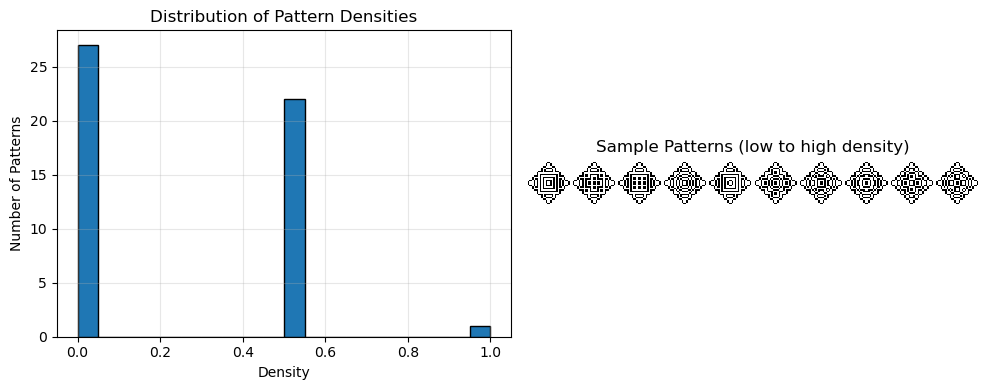

In [17]:
# Generate patterns for level 3 (8x8 patterns)
print("Generating level 3 patterns (8×8)...")
print("This will take a few minutes...\n")

level=5

# Use the public API to generate patterns
library_level3 = PatternLibrary.generate(level=level, solution_limit=50)

print(f"\n✓ Generated {len(library_level3.solutions)} unique patterns")

# Calculate densities
densities = library_level3.densities
print(f"  Density range: {densities.min():.3f} to {densities.max():.3f}")

# Visualize density distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(densities, bins=20, edgecolor='black')
plt.xlabel('Density')
plt.ylabel('Number of Patterns')
plt.title('Distribution of Pattern Densities')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
# Show sample of patterns
n_samples = min(10, len(library_level3.solutions))
indices = np.linspace(0, len(library_level3.solutions)-1, n_samples, dtype=int)
combined = np.hstack([library_level3.solutions[i] for i in indices])
plt.imshow(combined, cmap='binary', interpolation='nearest')
plt.title('Sample Patterns (low to high density)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Step 7: Verifying Still-Life Property

Let's verify that our generated patterns are indeed valid still-lifes by simulating them in Game of Life:

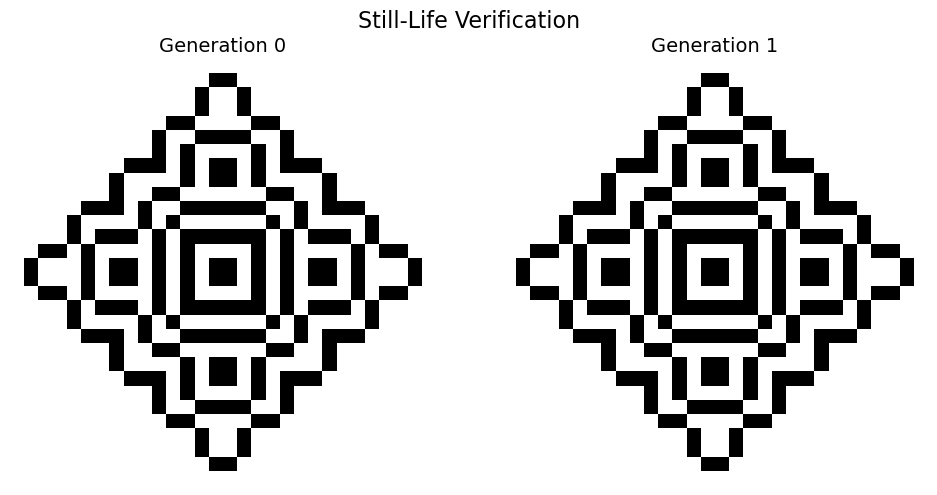

✓ Pattern is a valid still-life (unchanged after 1 generation)


In [18]:
def step_game_of_life(grid):
    """Advance Game of Life by one generation."""
    N = len(grid)
    new_grid = np.zeros_like(grid)
    
    for i in range(N):
        for j in range(N):
            # Count neighbors
            neighbors = 0
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < N and 0 <= nj < N:
                        neighbors += grid[ni, nj]
            
            # Apply rules
            if grid[i, j] == 1:  # Cell is alive
                new_grid[i, j] = 1 if neighbors in [2, 3] else 0
            else:  # Cell is dead
                new_grid[i, j] = 1 if neighbors == 3 else 0
    
    return new_grid

# Test a generated pattern
test_pattern = library_level3.solutions[len(library_level3.solutions)//2]  # Pick middle pattern
next_gen = step_game_of_life(test_pattern)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(test_pattern, cmap='binary', interpolation='nearest')
axes[0].set_title('Generation 0', fontsize=14)
axes[0].axis('off')

axes[1].imshow(next_gen, cmap='binary', interpolation='nearest')
axes[1].set_title('Generation 1', fontsize=14)
axes[1].axis('off')

plt.suptitle('Still-Life Verification', fontsize=16)
plt.tight_layout()
plt.show()

if np.array_equal(test_pattern, next_gen):
    print("✓ Pattern is a valid still-life (unchanged after 1 generation)")
else:
    print("✗ Pattern changed - not a still-life!")
    print(f"  Differences: {np.sum(test_pattern != next_gen)} cells")

## Step 8: Saving the Pattern Library

Once we've generated a complete set of patterns, we can save them to disk for reuse in mosaics:

In [20]:
SAVEFILES=False

if SAVEFILES:

    # Save patterns to file
    import os

    output_dir = '../data'
    os.makedirs(output_dir, exist_ok=True)

    output_file = os.path.join(output_dir, 'level3_solutions_test.npy')
    np.save(output_file, library_level3.solutions)

    print(f"✓ Saved {len(library_level3.solutions)} patterns to {output_file}")
    print(f"  File size: {os.path.getsize(output_file) / 1024:.1f} KB")

    # Verify we can load it back
    loaded = np.load(output_file)
    print(f"\n✓ Verified: Loaded {len(loaded)} patterns from file")
    print(f"  Shape: {loaded.shape}")

    # You can also load these patterns later using:
    # library = PatternLibrary.load(level=3)
    # This loads the pre-computed patterns from the data/ directory

## Step 9: Comparing Pattern Levels

Different levels produce patterns of different sizes and complexity:

- **Level 3**: 8×8 patterns (64 cells)
- **Level 4**: 16×16 patterns (256 cells)  
- **Level 5**: 32×32 patterns (1024 cells)
- **Level 6**: 64×64 patterns (4096 cells)

Higher levels allow for more complex patterns and finer density control, but take longer to compute.

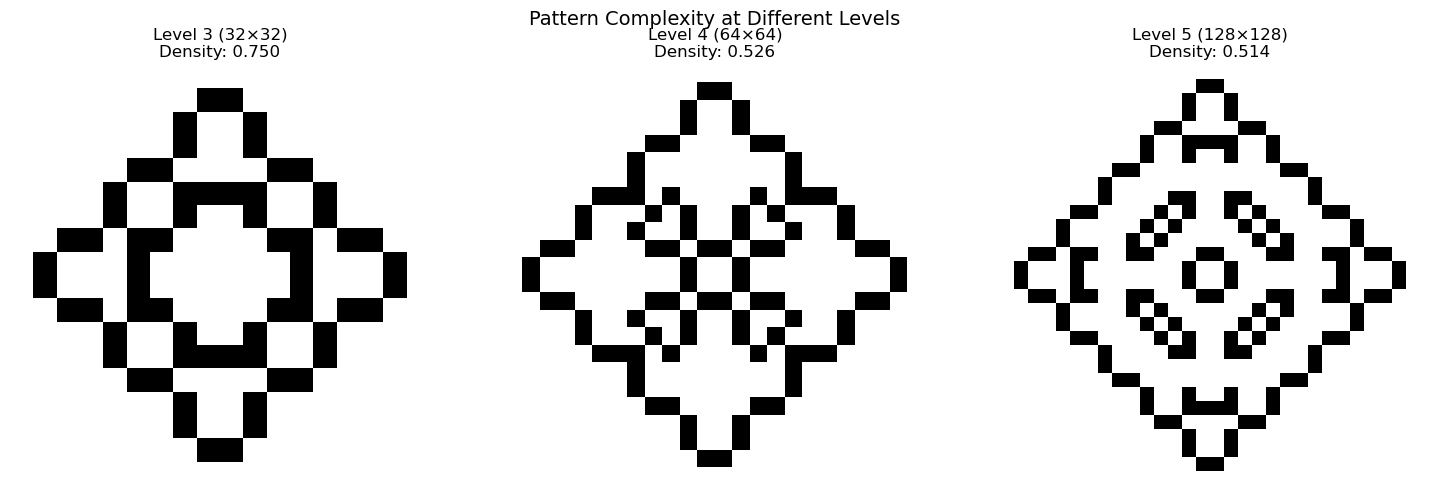

Notice how higher levels can achieve:
  - More intricate details
  - Better density precision
  - More varied structures


In [21]:
# Compare different levels
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

levels = [3, 4, 5]
target_density = 0.5

for ax, level in zip(axes, levels):
    library = PatternLibrary.load(level=level)
    
    # Find pattern closest to target density
    idx = np.argmin(np.abs(library.densities - target_density))
    pattern = library.solutions[idx]
    actual_density = library.densities[idx]
    
    size = 2**(level+2)
    ax.imshow(pattern, cmap='binary', interpolation='nearest')
    ax.set_title(f'Level {level} ({size}×{size})\nDensity: {actual_density:.3f}', fontsize=12)
    ax.axis('off')

plt.suptitle('Pattern Complexity at Different Levels', fontsize=14)
plt.tight_layout()
plt.show()

print("Notice how higher levels can achieve:")
print("  - More intricate details")
print("  - Better density precision")
print("  - More varied structures")

## Summary

We've covered the complete pipeline for generating Game of Life still-life patterns:

1. **Understanding still-lifes**: Stable patterns that don't change
2. **8-fold symmetry**: Reduces problem size by 8×
3. **Integer Linear Programming**: Formulating constraints for Gurobi
4. **Game of Life rules**: Each living cell has 2-3 neighbors, no births
5. **Density control**: Targeting specific fractions of living cells
6. **Pattern library**: Generating many patterns for mosaic creation
7. **Verification**: Confirming patterns are valid still-lifes

The resulting patterns form the building blocks for creating Game of Life mosaics from arbitrary images!

### Next Steps

- Try generating your own custom patterns with specific densities
- Experiment with larger levels (6 or 7) for more detail
- Use these patterns with `MosaicGenerator` to create artwork
- See the quickstart notebook for creating mosaics from images